# Reaction-Diffusion Turing Patterns (Gray–Scott)

Reaction-diffusion systems couple local nonlinear chemistry and diffusion:
$$
\partial_t U = D_u \Delta U - UV^2 + F(1-U),\qquad
\partial_t V = D_v \Delta V + UV^2 - (F+k)V.
$$
Different $(F,k)$ regimes yield spots, stripes, and labyrinths.

Gray--Scott dynamics couple diffusion with nonlinear reactions,
$$u_t=D_u\Delta u-uv^2+F(1-u),\qquad v_t=D_v\Delta v+uv^2-(F+k)v.$$
Small perturbations can be amplified into spots or stripes. Temporal snapshots show that pattern selection is a dynamical instability, not a static texture filter.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/reaction-diffusion-turing") if Path("python/reaction-diffusion-turing").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Gray–Scott simulation on a periodic grid

We initialize a perturbed square seed and evolve with explicit Euler and finite-difference Laplacian.


In [2]:
n = 140
Du, Dv = 0.16, 0.08
F, kappa = 0.034, 0.062
dt = 1.0
steps = 1800
snap_ids = [0, 300, 900, 1800]

rng = np.random.default_rng(1)
U = np.ones((n, n))
V = np.zeros((n, n))

s = 12
U[n//2-s:n//2+s, n//2-s:n//2+s] = 0.50
V[n//2-s:n//2+s, n//2-s:n//2+s] = 0.25
U += 0.02 * rng.standard_normal((n, n))
V += 0.02 * rng.standard_normal((n, n))

def lap(Z):
    return (np.roll(Z,1,0)+np.roll(Z,-1,0)+np.roll(Z,1,1)+np.roll(Z,-1,1)-4*Z)

snaps = {}
for it in range(steps + 1):
    if it in snap_ids:
        snaps[it] = V.copy()
    UVV = U * V * V
    U += dt * (Du * lap(U) - UVV + F*(1-U))
    V += dt * (Dv * lap(V) + UVV - (F+kappa)*V)


## Pattern snapshots through time

The $V$ component reveals emergent pattern scales and morphology transitions.


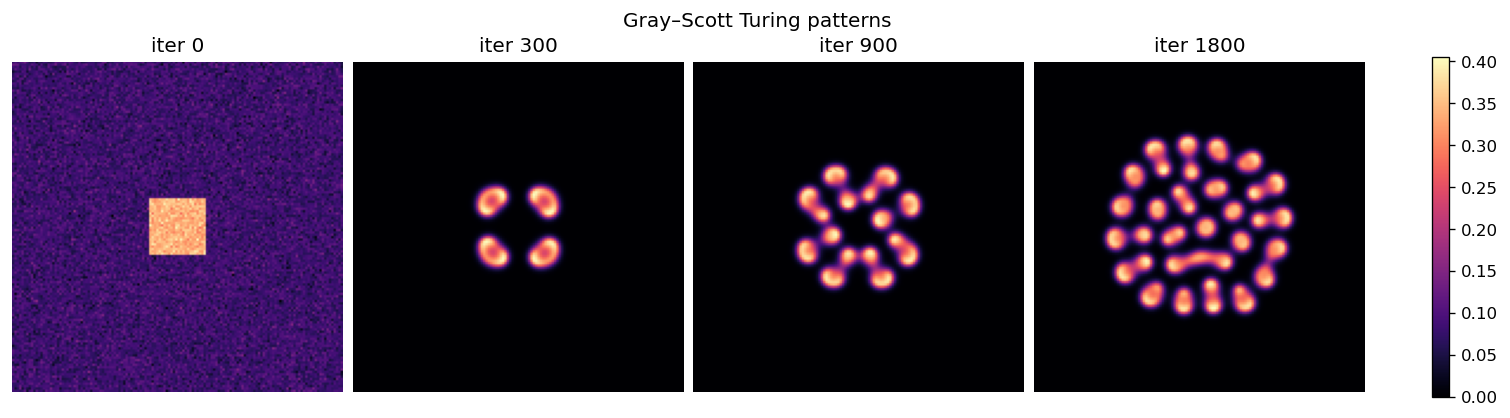

In [3]:
fig, axes = plt.subplots(1, len(snap_ids), figsize=(12.5, 3.2), layout="constrained")
for ax, it in zip(axes, snap_ids):
    im = ax.imshow(snaps[it], cmap="magma", origin="lower")
    ax.set_title(f"iter {it}")
    ax.axis("off")
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025)
fig.suptitle("Gray–Scott Turing patterns", y=1.04)
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- A. M. Turing, "The Chemical Basis of Morphogenesis", Phil. Trans. Roy. Soc. B, 1952.
- J. D. Murray, *Mathematical Biology II: Spatial Models and Biomedical Applications*, Springer, 2003.
- P. Grindrod, *Patterns and Waves: The Theory and Applications of Reaction-Diffusion Equations*, Oxford Univ. Press, 1996.
